# HUẤN LUYỆN CÁC MÔ HÌNH VÀ ĐÁNH GIÁ KẾT QUẢ

## 1. Nạp dữ liệu từ Preprocessing_data

In [ ]:
# Thực hiện chạy toàn bộ mã trong file preprocessing_data.ipynb
# Tất cả dữ liệu và biến trong file đó sẽ được tải vào môi trường hiện tại

%run preprocessing_data.ipynb

## 2. Thiết lập môi trường

### a) Import thư viện

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

### b) Chuẩn bị các mô hình

In [25]:
# Cấu hình MLP dùng chung cho các thí nghiệm phân loại
mlp_classifier_params = {
    "hidden_layer_sizes": (128, 64),
    "activation": "relu",
    "solver": "adam",
    "alpha": 0.001,
    "batch_size": 128,
    "learning_rate_init": 0.001,
    "max_iter": 200,
    "early_stopping": True,
    "validation_fraction": 0.1,
    "n_iter_no_change": 10,
    "random_state": 42
}

def build_mlp_classifier():
    return make_pipeline(
        StandardScaler(),
        MLPClassifier(**mlp_classifier_params)
    )

def build_svm_classifier():
    return make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', cache_size=1000, random_state=42)
    )

# Tạo một dictionary chứa các mô hình
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression (Softmax)": LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42),
    "MLP Classifier": build_mlp_classifier(),
    "SVM (RBF Kernel)": build_svm_classifier()
}

#Tạo một danh sách các dictionary, mỗi dictionary đại diện cho một thí nghiệm ứng với cách chia tỉ lệ dữ liệu và loại dữ liệu khác nhau
experiments = [
    #Dữ liệu HOG gốc
    {
        "name": "HOG Gốc - Tỉ lệ 4:1",
        "X_train": X_train_hog_41, "y_train": y_train_hog_41,
        "X_val": X_val_hog_41, "y_val": y_val_hog_41
    },
    {
        "name": "HOG Gốc - Tỉ lệ 7:3",
        "X_train": X_train_hog_73, "y_train": y_train_hog_73,
        "X_val": X_val_hog_73, "y_val": y_val_hog_73
    },
    {
        "name": "HOG Gốc - Tỉ lệ 6:4",
        "X_train": X_train_hog_64, "y_train": y_train_hog_64,
        "X_val": X_val_hog_64, "y_val": y_val_hog_64
    },
    #Dữ liệu sau khi giảm chiều bằng PCA
    {
        "name": "Sau PCA - Tỉ lệ 4:1",
        "X_train": X_train_41_pca, "y_train": Y_train_41_pca,
        "X_val": X_val_41_pca, "y_val": Y_val_41_pca
    },
    {
        "name": "Sau PCA - Tỉ lệ 7:3",
        "X_train": X_train_73_pca, "y_train": Y_train_73_pca,
        "X_val": X_val_73_pca, "y_val": Y_val_73_pca
    },
    {
        "name": "Sau PCA - Tỉ lệ 6:4",
        "X_train": X_train_64_pca, "y_train": Y_train_64_pca,
        "X_val": X_val_64_pca, "y_val": Y_val_64_pca
    },
    #Dữ liệu sau khi giảm chiều bằng LDA
    {
        "name": "Sau LDA - Tỉ lệ 4:1",
        "X_train": X_train_41_lda, "y_train": Y_train_41_lda,
        "X_val": X_val_41_lda, "y_val": Y_val_41_lda
    },
    {
        "name": "Sau LDA - Tỉ lệ 7:3",
        "X_train": X_train_73_lda, "y_train": Y_train_73_lda,
        "X_val": X_val_73_lda, "y_val": Y_val_73_lda
    },
    {
        "name": "Sau LDA - Tỉ lệ 6:4",
        "X_train": X_train_64_lda, "y_train": Y_train_64_lda,
        "X_val": X_val_64_lda, "y_val": Y_val_64_lda
    },
]

#Nơi lưu trữ kết quả
results_list = []

print("Đã sẵn sàng chạy các mô hình...\n")

Đã sẵn sàng chạy các mô hình...



## 3. Huấn luyện và đánh giá các mô hình trên tập train/validation

In [26]:
print("BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN VÀ ĐÁNH GIÁ\n" + "="*50)

#Lặp qua từng thí nghiệm
for exp in experiments:
    print(f"\n--- Thí nghiệm: {exp['name']} ---")
    
    #Lấy dữ liệu từ dictionary của thí nghiệm
    X_train_sub, y_train_sub = exp['X_train'], exp['y_train']
    X_val, y_val = exp['X_val'], exp['y_val']

    #Lặp qua từng mô hình
    for m_name, model in models.items():
        #Huấn luyện mô hình trên tập train_sub
        model.fit(X_train_sub, y_train_sub)

        #Dự đoán trên cả tập train và validation để so sánh
        y_train_pred = model.predict(X_train_sub)
        y_val_pred = model.predict(X_val)

        #Tính toán độ chính xác
        train_accuracy = accuracy_score(y_train_sub, y_train_pred)
        val_accuracy = accuracy_score(y_val, y_val_pred)

        #Lưu kết quả vào danh sách kết quả
        results_list.append({
            "Thí nghiệm": exp['name'],
            "Mô hình": m_name,
            "Accuracy (Train)": train_accuracy,
            "Accuracy (Validation)": val_accuracy
        })

print("\n" + "="*50 + "\nQUÁ TRÌNH HUẤN LUYỆN VÀ ĐÁNH GIÁ ĐÃ HOÀN TẤT!")

BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN VÀ ĐÁNH GIÁ

--- Thí nghiệm: HOG Gốc - Tỉ lệ 4:1 ---

--- Thí nghiệm: HOG Gốc - Tỉ lệ 7:3 ---

--- Thí nghiệm: HOG Gốc - Tỉ lệ 6:4 ---

--- Thí nghiệm: Sau PCA - Tỉ lệ 4:1 ---

--- Thí nghiệm: Sau PCA - Tỉ lệ 7:3 ---

--- Thí nghiệm: Sau PCA - Tỉ lệ 6:4 ---

--- Thí nghiệm: Sau LDA - Tỉ lệ 4:1 ---

--- Thí nghiệm: Sau LDA - Tỉ lệ 7:3 ---

--- Thí nghiệm: Sau LDA - Tỉ lệ 6:4 ---

QUÁ TRÌNH HUẤN LUYỆN VÀ ĐÁNH GIÁ ĐÃ HOÀN TẤT!


## 4. Tổng hợp kết quả Training

In [27]:
results_df = pd.DataFrame(results_list)


split_data = results_df['Thí nghiệm'].str.split(' - Tỉ lệ ', expand=True)
results_df['Loại dữ liệu'] = split_data[0]
results_df['Tỉ lệ chia'] = split_data[1]


#Bảng so sánh hiệu suất chính (chỉ trên tập Validation)
pivot_df = results_df.pivot_table(
    index=['Tỉ lệ chia', 'Loại dữ liệu'],
    columns='Mô hình',
    values='Accuracy (Validation)'
)

# Định dạng lại các số trong bảng để hiển thị 4 chữ số thập phân
formatted_pivot = pivot_df.applymap('{:.4f}'.format)

print("BẢNG 1: SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH TRÊN TẬP VALIDATION")
print("="*85)
print(formatted_pivot)
print("\n" + "="*85)


#Bảng đầy đủ để phân tích Overfitting
#Tính toán độ chênh lệch giữa accuracy của tập train và validation
results_df['Chênh lệch (Train-Val)'] = results_df['Accuracy (Train)'] - results_df['Accuracy (Validation)']

sorted_df = results_df.sort_values(by=['Tỉ lệ chia', 'Loại dữ liệu'])

print("\nBẢNG 2: DỮ LIỆU ĐẦY ĐỦ ĐỂ PHÂN TÍCH OVERFITTING")
print("="*85)
print(sorted_df[[
    "Tỉ lệ chia",
    "Loại dữ liệu",
    "Mô hình",
    "Accuracy (Train)",
    "Accuracy (Validation)",
    "Chênh lệch (Train-Val)"
]].to_string())

BẢNG 1: SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH TRÊN TẬP VALIDATION
Mô hình                 Logistic Regression (Softmax) MLP Classifier  \
Tỉ lệ chia Loại dữ liệu                                                
4:1        HOG Gốc                             0.8355         0.8784   
           Sau LDA                             0.7533         0.7375   
           Sau PCA                             0.8241         0.7804   
6:4        HOG Gốc                             0.8319         0.8700   
           Sau LDA                             0.7479         0.7304   
           Sau PCA                             0.8289         0.7751   
7:3        HOG Gốc                             0.8378         0.8757   
           Sau LDA                             0.7246         0.7112   
           Sau PCA                             0.8285         0.8022   

Mô hình                 Naive Bayes SVM (RBF Kernel)  
Tỉ lệ chia Loại dữ liệu                               
4:1        HOG Gốc           0.6439    

## 5. Huấn luyện và dự đoán bằng toàn bộ dữ liệu

In [28]:
# Tạo một dictionary chứa các dữ liệu cần thiết
final_datasets = {
    "HOG Gốc": (X_train_hog, X_test_hog),
    "Sau PCA": (X_train_pca, X_test_pca),
    "Sau LDA": (X_train_lda, X_test_lda)
}

# Tạo một dictionary chứa các mô hình
final_models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression (Softmax)": LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42),
    "MLP Classifier": build_mlp_classifier(),
    "SVM (RBF Kernel)": build_svm_classifier()
}

# Chuẩn bị nơi lưu kết quả cuối cùng
final_results_list = []
class_names = label_encoder.classes_

print("\nBẮT ĐẦU QUÁ TRÌNH ĐÁNH GIÁ TRÊN TOÀN BỘ TẬP DỮ LIỆU")
print("="*60)

#Lặp qua các loại dữ liệu và mô hình
for data_name, (X_train, X_test) in final_datasets.items():
    print(f"\n---------- Đang xử lý trên dữ liệu: {data_name} ----------")
    for model_name, model in final_models.items():
        print(f"\n>>>>> Mô hình: {model_name} <<<<<")
        
        # Huấn luyện mô hình trên bộ dữ liệu train tương ứng
        model.fit(X_train, y_train_encoded)
        
        # Dự đoán trên tập test tương ứng
        y_test_pred = model.predict(X_test)
        y_train_pred = model.predict(X_train)
        
        # Tính toán và in kết quả
        accuracy = accuracy_score(y_test_encoded, y_test_pred)
        report = classification_report(y_test_encoded, y_test_pred, target_names=class_names, zero_division=0)

        accuracy_train = accuracy_score(y_train_encoded, y_train_pred)
        print(f"Độ chính xác tổng thể trên tập Train: {accuracy_train:.4f}")
        print(f"Độ chính xác tổng thể trên tập Test: {accuracy:.4f}")
        
        print(f"Chênh lệch độ chính xác (Train - Test): {accuracy_train - accuracy:.4f}")
        
        print("Báo cáo phân loại chi tiết:")
        print(report)
        
        # Lưu kết quả vào danh sách
        final_results_list.append({
            "Loại dữ liệu": data_name,
            "Mô hình": model_name,
            "Test Accuracy": accuracy
        })

#Tổng hợp và in bảng kết quả
print("\n" + "="*60)
print("BẢNG TÓM TẮT KẾT QUẢ CUỐI CÙNG")
print("="*60)

final_results_df = pd.DataFrame(final_results_list)
pivot_final = final_results_df.pivot_table(
    index='Loại dữ liệu',
    columns='Mô hình',
    values='Test Accuracy'
)
print(pivot_final.applymap('{:.4f}'.format))


BẮT ĐẦU QUÁ TRÌNH ĐÁNH GIÁ TRÊN TOÀN BỘ TẬP DỮ LIỆU

---------- Đang xử lý trên dữ liệu: HOG Gốc ----------

>>>>> Mô hình: Naive Bayes <<<<<
Độ chính xác tổng thể trên tập Train: 0.6717
Độ chính xác tổng thể trên tập Test: 0.6171
Chênh lệch độ chính xác (Train - Test): 0.0547
Báo cáo phân loại chi tiết:
              precision    recall  f1-score   support

      glioma       0.50      0.57      0.53       300
  meningioma       0.46      0.48      0.47       306
     notumor       0.80      0.76      0.78       405
   pituitary       0.68      0.62      0.65       300

    accuracy                           0.62      1311
   macro avg       0.61      0.61      0.61      1311
weighted avg       0.63      0.62      0.62      1311


>>>>> Mô hình: Logistic Regression (Softmax) <<<<<
Độ chính xác tổng thể trên tập Train: 1.0000
Độ chính xác tổng thể trên tập Test: 0.8635
Chênh lệch độ chính xác (Train - Test): 0.1365
Báo cáo phân loại chi tiết:
              precision    recall  f1-scor

## 6. Huấn luyện và đánh giá mô hình tốt nhất


In [31]:
print("--- HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT ---")
print("="*70)

# Dựa trên bảng kết quả ở phần trên, mô hình tốt nhất là SVM RBF trên dữ liệu HOG gốc.
print("Mô hình tốt nhất: SVM (RBF Kernel) trên dữ liệu HOG gốc.")
champion_model = build_svm_classifier()

# Huấn luyện trên toàn bộ tập train HOG gốc
champion_model.fit(X_train_hog, y_train_encoded)

# Dự đoán và đánh giá trên tập test HOG gốc
y_test_pred = champion_model.predict(X_test_hog)
y_train_pred = champion_model.predict(X_train_hog)

print("\n--- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG ---")
test_accuracy = accuracy_score(y_test_encoded, y_test_pred)
train_accuracy = accuracy_score(y_train_encoded, y_train_pred)
print(f"Độ chính xác tổng thể trên tập Train: {train_accuracy:.4f} ({train_accuracy:.2%})")
print(f"Độ chính xác tổng thể trên tập Test: {test_accuracy:.4f} ({test_accuracy:.2%})")
print(f"Chênh lệch độ chính xác (Train - Test): {train_accuracy - test_accuracy:.4f}")

class_names = label_encoder.classes_
print("\nBáo cáo phân loại chi tiết (Classification Report):")
print(classification_report(y_test_encoded, y_test_pred, target_names=class_names, zero_division=0))


--- HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT ---
Mô hình tốt nhất: SVM (RBF Kernel) trên dữ liệu HOG gốc.

--- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG ---
Độ chính xác tổng thể trên tập Train: 1.0000 (100.00%)
Độ chính xác tổng thể trên tập Test: 0.9230 (92.30%)
Chênh lệch độ chính xác (Train - Test): 0.0770

Báo cáo phân loại chi tiết (Classification Report):
              precision    recall  f1-score   support

      glioma       0.90      0.84      0.87       300
  meningioma       0.86      0.87      0.87       306
     notumor       0.98      1.00      0.99       405
   pituitary       0.92      0.96      0.94       300

    accuracy                           0.92      1311
   macro avg       0.92      0.92      0.92      1311
weighted avg       0.92      0.92      0.92      1311



### Trực quan hóa và đánh giá tương quan giữa dự đoán – thực tế.

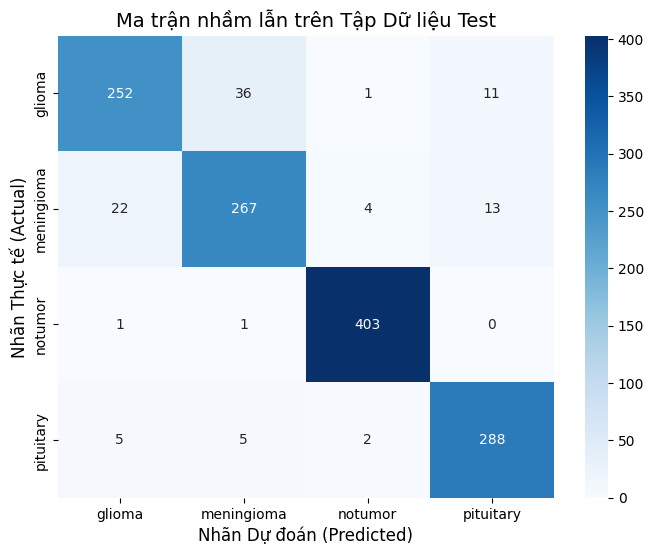

In [32]:
#Tính toán ma trận nhầm lẫn
cm = confusion_matrix(y_test_encoded, y_test_pred)

# Lấy tên của các lớp để hiển thị trên biểu đồ
class_names = label_encoder.classes_

#Vẽ ma trận dưới dạng heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

# Thêm tiêu đề và nhãn cho các trục
plt.title('Ma trận nhầm lẫn trên Tập Dữ liệu Test', fontsize=14)
plt.ylabel('Nhãn Thực tế (Actual)', fontsize=12)
plt.xlabel('Nhãn Dự đoán (Predicted)', fontsize=12)
plt.show()